In [1]:
#! pip install matplotlib

In [2]:
#! pip install tensorflow


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Laptop GPU


## Data Preprocessing.

In [3]:
import zipfile
import os

zip_path = "archive.zip"   # your local file
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

Extracted successfully!


In [ ]:
# import tensorflow as tf

# PATH = r"E:\Projects\Cats and dogs\data\PetImages"

In [ ]:
# import os
# from PIL import Image
# # 
# corrupt_files = []

# for folder in ["Cat", "Dog"]:
#     folder_path = os.path.join(PATH, folder)

#     for file in os.listdir(folder_path):
#         file_path = os.path.join(folder_path, file)

#         try:
#             img = Image.open(file_path)
#             img.verify()   # checks if image is valid
#         except:
#             corrupt_files.append(file_path)

# print("Corrupt images found:", len(corrupt_files))

Corrupt images found: 4


c:\Python\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
# for file_path in corrupt_files:
#     os.remove(file_path)
#     print("Deleted:", file_path)

Deleted: E:\Projects\Cats and dogs\data\PetImages\Cat\666.jpg
Deleted: E:\Projects\Cats and dogs\data\PetImages\Cat\Thumbs.db
Deleted: E:\Projects\Cats and dogs\data\PetImages\Dog\11702.jpg
Deleted: E:\Projects\Cats and dogs\data\PetImages\Dog\Thumbs.db


In [4]:
import os
import tensorflow as tf

PATH = r"E:\Projects\Cats and dogs\data\PetImages"

removed = 0
for folder in ["Cat", "Dog"]:  # your class folders
    folder_path = os.path.join(PATH, folder)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            img = tf.io.read_file(fpath)
            tf.image.decode_image(img, channels=3)
        except Exception:
            print(f"Removing corrupt file: {fpath}")
            os.remove(fpath)
            removed += 1

print(f"\nDone. Removed {removed} corrupt image(s).")

Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Cat\10404.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Cat\4351.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Cat\666.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Cat\Thumbs.db
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\11233.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\11702.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\11912.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\2317.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\2494.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\9500.jpg
Removing corrupt file: E:\Projects\Cats and dogs\data\PetImages\Dog\Thumbs.db

Done. Removed 11 corrupt image(s).


In [5]:
import tensorflow as tf

PATH = r"E:\Projects\Cats and dogs\data\PetImages"

BATCH_SIZE = 32
IMG_SIZE = (160, 160)
 ##
# train_dataset = tf.keras.utils.image_dataset_from_directory(
# PATH,
# validation_split=0.2,     # 80% train, 20% validation
# subset="training",
# seed=123,
# shuffle=True,
# batch_size=BATCH_SIZE,
# image_size=IMG_SIZE
# ) */
train_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(160, 160),
    batch_size=32,
    shuffle=True,
    label_mode="int"
)


validation_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [6]:
print(validation_dataset.class_names)

['Cat', 'Dog']


In [7]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 160, 160, 3)
Labels shape: (32,)


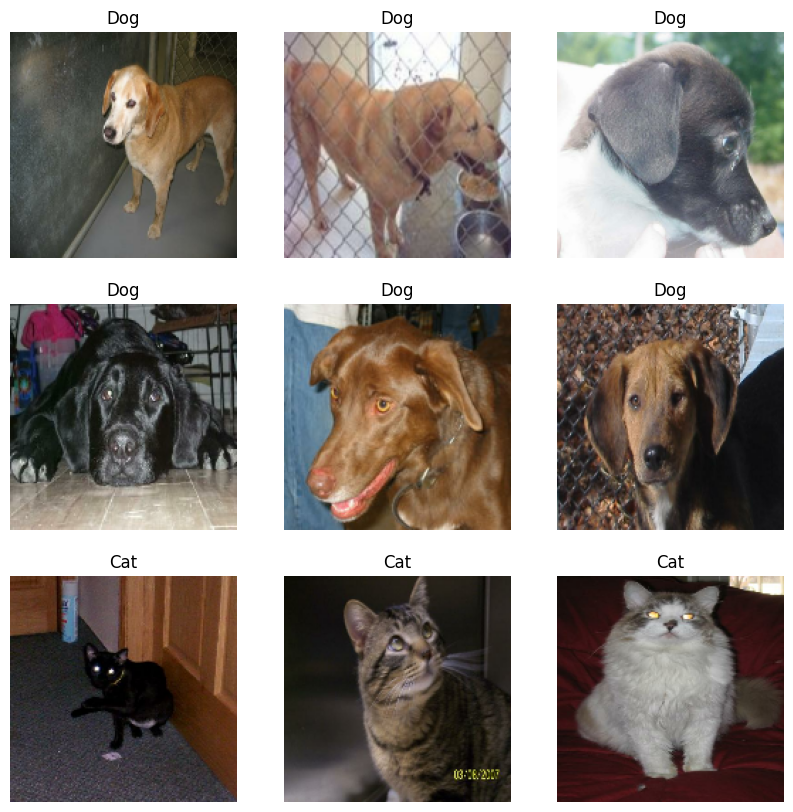

In [8]:
import matplotlib.pyplot as plt

class_names = validation_dataset.class_names

plt.figure(figsize=(10,10))

for images, labels in validation_dataset.take(3):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [9]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

In [10]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 126
Number of test batches: 31


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## Data Augmentation (To reduce overfiting)

In [12]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

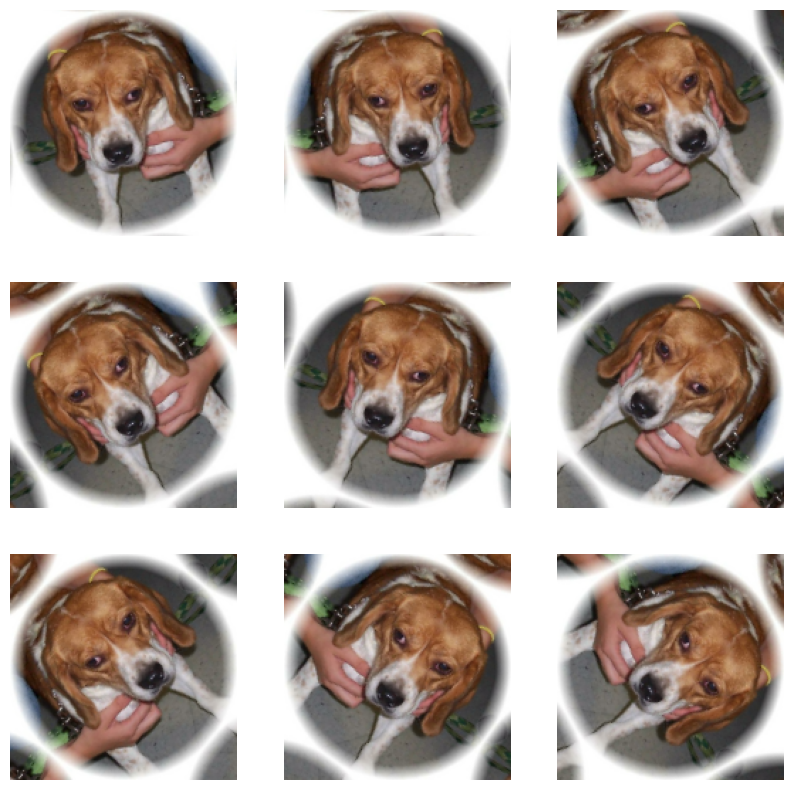

In [13]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[2]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image,0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [14]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [15]:
# import matplotlib.pyplot as plt

# class_names = train_dataset.class_names

# plt.figure(figsize=(10, 10))

# for images, labels in train_dataset.take(1):
#     for i in range(9):
#         ax = plt.subplot(3, 3, i + 1)
#         plt.imshow(images[i].numpy().astype("uint8"))
#         plt.title(class_names[labels[i]])
#         plt.axis("off")

## Create the base model from the pre-trained convnets

In [16]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

In [17]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


## Feature Extraction

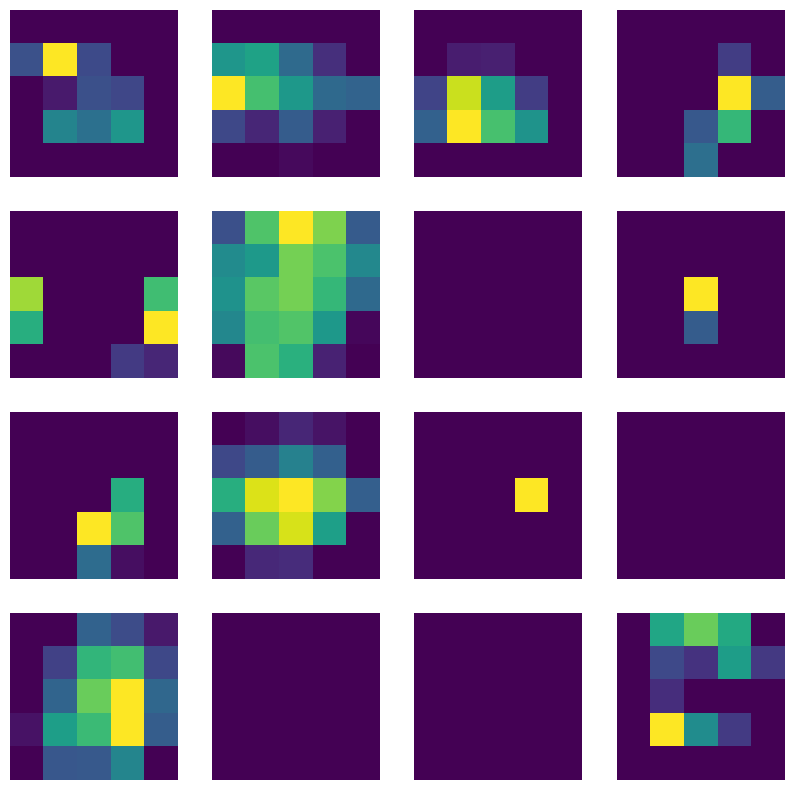

In [18]:
import matplotlib.pyplot as plt

feature = feature_batch[2]  # third image

plt.figure(figsize=(10, 10))
for i in range(16):  # show first 16 feature channels
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(feature[:, :, i])
    plt.axis("off")

In [19]:
base_model.trainable = False # Freeze the convolutional base


In [20]:
base_model.summary()


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Adding Classification Head

In [21]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [22]:
prediction_layer = tf.keras.layers.Dense(1, activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 1)


In [23]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [24]:
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
len(model.trainable_variables)


2

In [27]:
# ! pip install pydot

In [28]:
tf.keras.utils.plot_model(model, show_shapes=True)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [29]:
# ! pip install graphviz

In [30]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')])

## Train the model

In [31]:
initial_epochs = 10

loss0, accuracy0 = model.evaluate(validation_dataset)

126/126 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.6450 - loss: 0.6350


In [32]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 0.64
initial accuracy: 0.65


In [33]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)
            
            

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 251ms/step - accuracy: 0.8660 - loss: 0.3220 - val_accuracy: 0.9663 - val_loss: 0.1237
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - accuracy: 0.9331 - loss: 0.1740 - val_accuracy: 0.9753 - val_loss: 0.0860
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.9425 - loss: 0.1466 - val_accuracy: 0.9765 - val_loss: 0.0748
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 231ms/step - accuracy: 0.9451 - loss: 0.1399 - val_accuracy: 0.9790 - val_loss: 0.0678
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 221ms/step - accuracy: 0.9485 - loss: 0.1275 - val_accuracy: 0.9795 - val_loss: 0.0638
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 229ms/step - accuracy: 0.9532 - loss: 0.1200 - val_accuracy: 0.9785 - val_loss: 0.0623
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9513 - loss: 0.1214 - val_accuracy: 0.9803 - val_loss: 0.0595
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.9530 -

## Learning curves

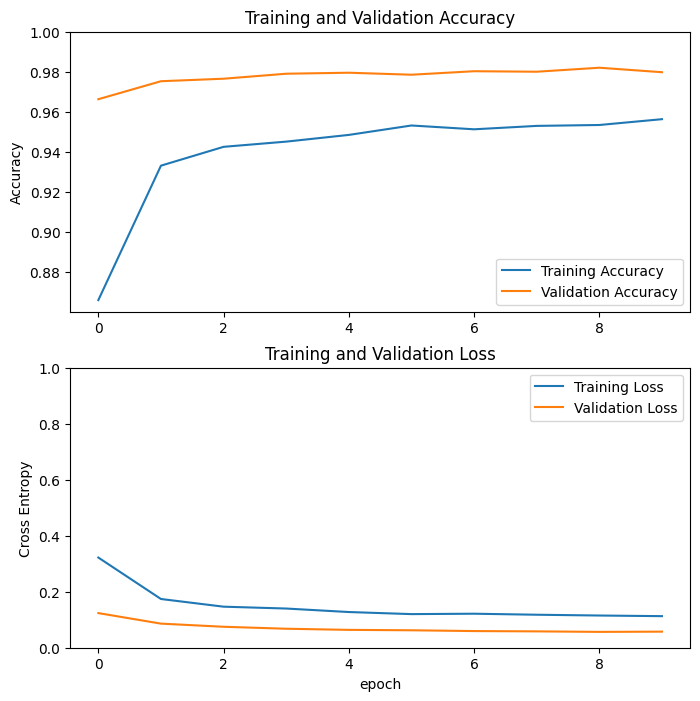

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

# Finetuning

## Un-freeze the top layers of the model

In [35]:
base_model.trainable = True

In [36]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


## Compile the model

In [37]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')])

In [38]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [39]:
len(model.trainable_variables)

56

## Continue training the model

In [40]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 350ms/step - accuracy: 0.9221 - loss: 0.1873 - val_accuracy: 0.9815 - val_loss: 0.0528
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 298s 477ms/step - accuracy: 0.9450 - loss: 0.1411 - val_accuracy: 0.9843 - val_loss: 0.0435
Epoch 13/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 411ms/step - accuracy: 0.9509 - loss: 0.1207 - val_accuracy: 0.9843 - val_loss: 0.0423
Epoch 14/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 272s 435ms/step - accuracy: 0.9573 - loss: 0.1099 - val_accuracy: 0.9858 - val_loss: 0.0422
Epoch 15/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 288s 461ms/step - accuracy: 0.9583 - loss: 0.1046 - val_accuracy: 0.9860 - val_loss: 0.0386
Epoch 16/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 291s 466ms/step - accuracy: 0.9641 - loss: 0.0936 - val_accuracy: 0.9875 - val_loss: 0.0380
Epoch 17/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 282s 451ms/step - accuracy: 0.9653 - loss: 0.0902 - val_accuracy: 0.9870 - val_loss: 0.0381
Epoch 18/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 273s 437ms/step - accuracy: 

In [41]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

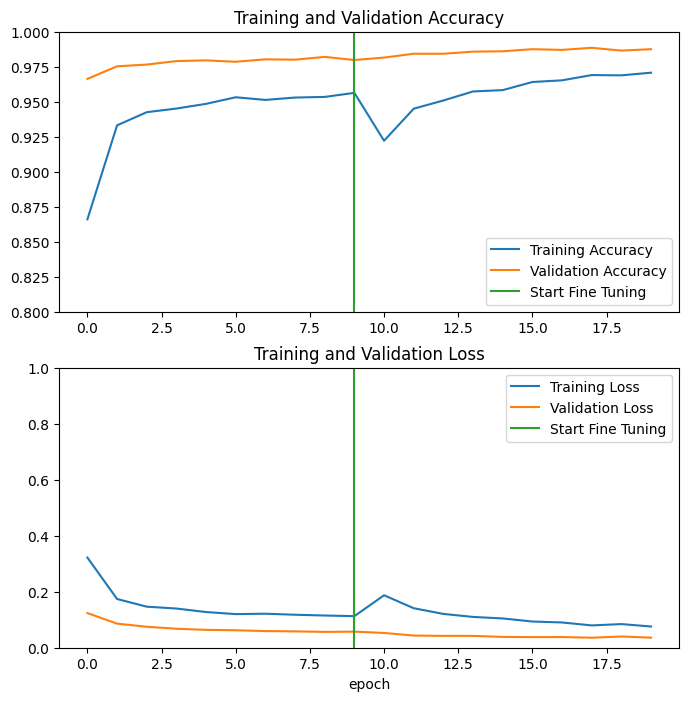

In [42]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## Evaluation and prediction

In [43]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.9859 - loss: 0.0360
Test accuracy : 0.9858871102333069


Predictions:
 [0 1 0 1 0 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0]
Labels:
 [0 1 0 0 0 0 0 1 0 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0]


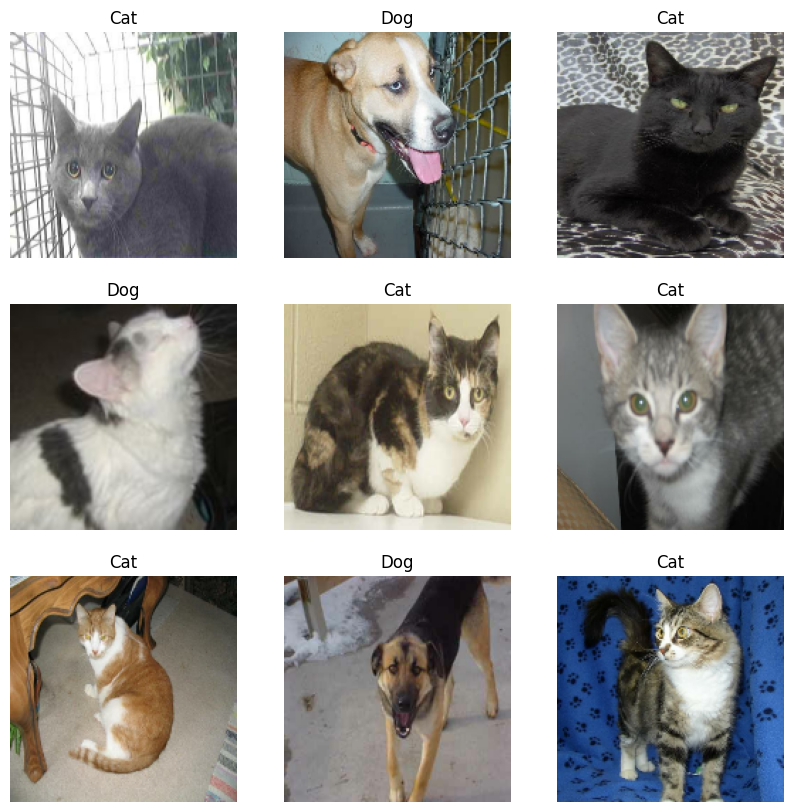

In [44]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")